Dataset Shape: (1600, 4)


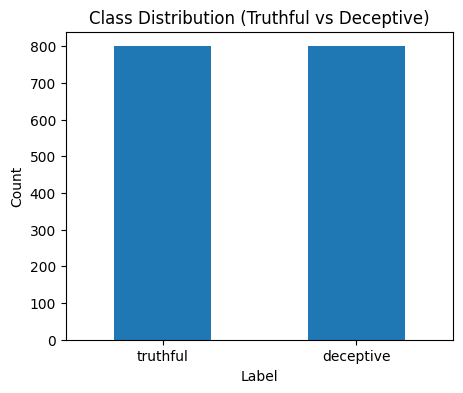

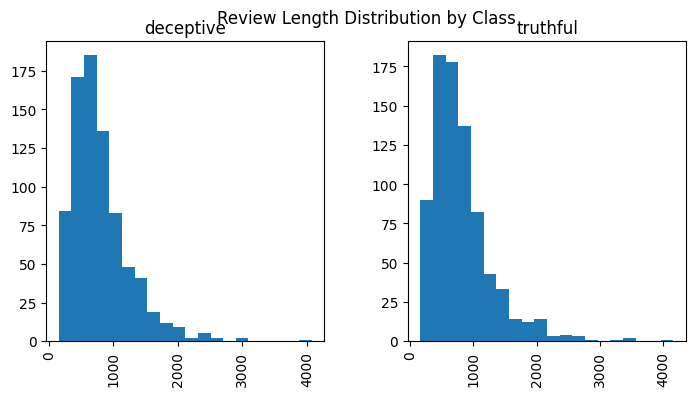

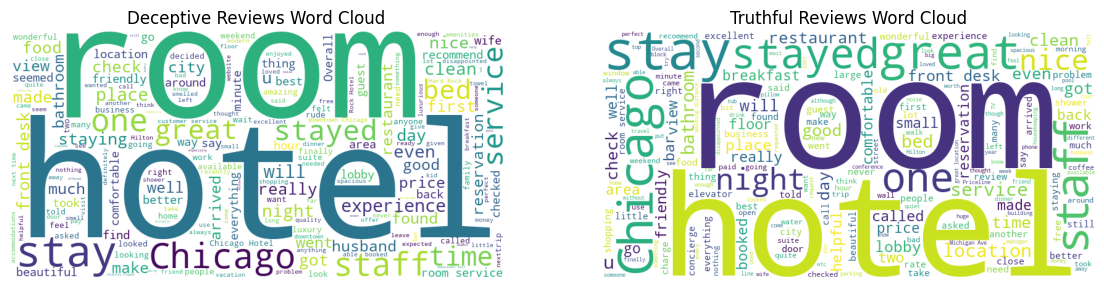

EDA completed successfully on the cleaned deceptive reviews dataset.


In [5]:
# ==============================
# ReviewGuard: Exploratory Data Analysis (EDA)
# ==============================

# Step 0: Imports
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

%matplotlib inline

# ==============================
# Step 1: Load Dataset
# ==============================

# Load cleaned CSV dataset
df = pd.read_csv("../data/raw/cleaned_base_deceptive_reviews.csv")

print("Dataset Shape:", df.shape)
df.head()

# ==============================
# Step 2: Select Relevant Columns
# ==============================

# Keep only review text and label
df = df[['Review', 'Label']]

# Rename for consistency
df.columns = ['review', 'label']

df.head()

# ==============================
# Step 3: Class Distribution
# ==============================

plt.figure(figsize=(5,4))
df['label'].value_counts().plot(
    kind='bar',
    title='Class Distribution (Truthful vs Deceptive)',
    rot=0
)
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# ==============================
# Step 4: Review Length Analysis
# ==============================

df['review_length'] = df['review'].astype(str).apply(len)

df.hist(
    column='review_length',
    by='label',
    bins=20,
    figsize=(8,4)
)
plt.suptitle("Review Length Distribution by Class")
plt.show()

# ==============================
# Step 5: Word Cloud Analysis
# ==============================

deceptive_text = ' '.join(df[df.label == 'deceptive'].review.astype(str))
truthful_text = ' '.join(df[df.label == 'truthful'].review.astype(str))

wc_deceptive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(deceptive_text)

wc_truthful = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(truthful_text)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(wc_deceptive)
plt.title("Deceptive Reviews Word Cloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_truthful)
plt.title("Truthful Reviews Word Cloud")
plt.axis("off")

plt.show()

# ==============================
# Step 6: Final Notes
# ==============================

print("EDA completed successfully on the cleaned deceptive reviews dataset.")
